<a href="https://colab.research.google.com/github/LeideMarina18/CRIAR_FOTOGRAFIA_COMPUTACIONAL_2026/blob/main/atividade_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática 01 - Fotografia Computacional

### Desafio
Desenvolver um pipeline de processamento que receba uma fotografia com problemas de qualidade e produza uma versão melhorada, equilibrando qualidade visual e preservação de detalhes.

## 1. Carregamento e análise da imagem
### Objetivos
Carregar e representar uma imagem digital;
identificar dimensões, canais, tipo de dado e faixa de intensidades;
observar histogramas e formular um diagnóstico inicial.
Instruções
Defina o caminho de uma fotografia e carregue-a com OpenCV. Exiba a imagem, apresente suas propriedades e salve uma cópia na pasta de resultados.

In [32]:
# Célula de preparação — execute antes das demais
from pathlib import Path
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['image.cmap'] = 'gray'

OUT_FOLDER = Path('./resultados')

if not os.path.exists(OUT_FOLDER): os.makedirs(OUT_FOLDER)

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# TODO 1.1 — substitua pelo caminho da sua fotografia
imagepath = Path('/content/drive/MyDrive/ColabNotebooks/inputs/IMG_0916.JPG')

# TODO 1.2 — carregue a imagem e verifique se a leitura funcionou
cv_image = cv2.imread(str(imagepath))
# TODO 1.3 — converta para tons de cinza
gray_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2GRAY)

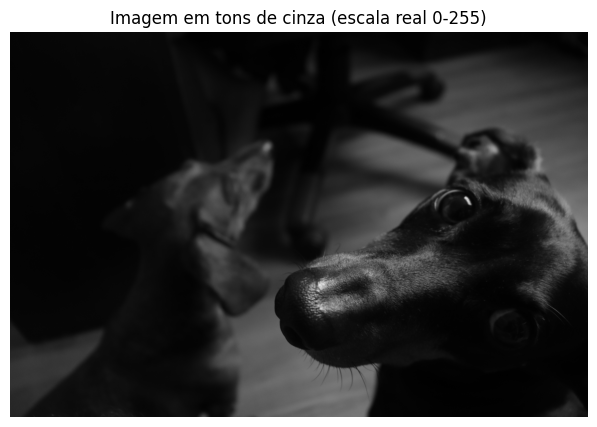

In [35]:
plt.imshow(gray_image, vmin=0, vmax=255)
plt.title('Imagem em tons de cinza (escala real 0-255)')
plt.axis('off')
plt.show()

### TODO 1.4 — informe altura, largura, canais, dtype, mínimo, máximo e memória ocupada

In [36]:
shape = cv_image.shape
height, width = shape[:2]
channels = shape[2] if cv_image.ndim == 3 else 1
type_ = cv_image.dtype
min_value = cv_image.min()
max_value = cv_image.max()
memory = cv_image.nbytes

print(f"Shape:           {shape}")
print(f"Altura:          {height} px")
print(f"Largura:         {width} px")
print(f"Canais:          {channels}")
print(f"Tipo de dado:    {type_}")
print(f"Valor mínimo:    {min_value}")
print(f"Valor máximo:    {max_value}")
print(f"Memória:         {memory} bytes ({memory / 1024**2:.2f} MB)")

Shape:           (4000, 6000, 3)
Altura:          4000 px
Largura:         6000 px
Canais:          3
Tipo de dado:    uint8
Valor mínimo:    0
Valor máximo:    247
Memória:         72000000 bytes (68.66 MB)


### TODO 1.5 — exiba lado a lado a imagem colorida e a versão em cinza


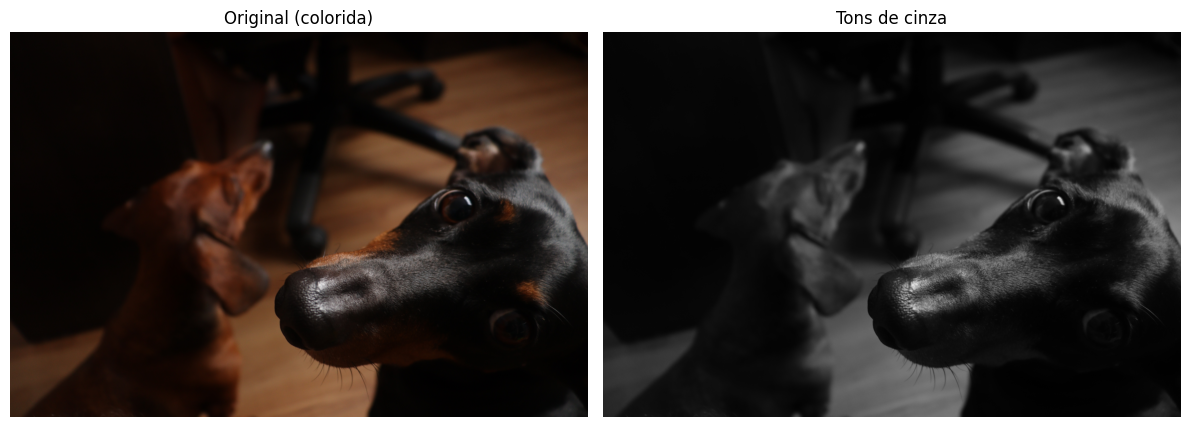

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (colorida)')
axes[0].axis('off')

axes[1].imshow(gray_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Tons de cinza')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### TODO 1.6 — produza histogramas adequados (cinza e/ou por canal)

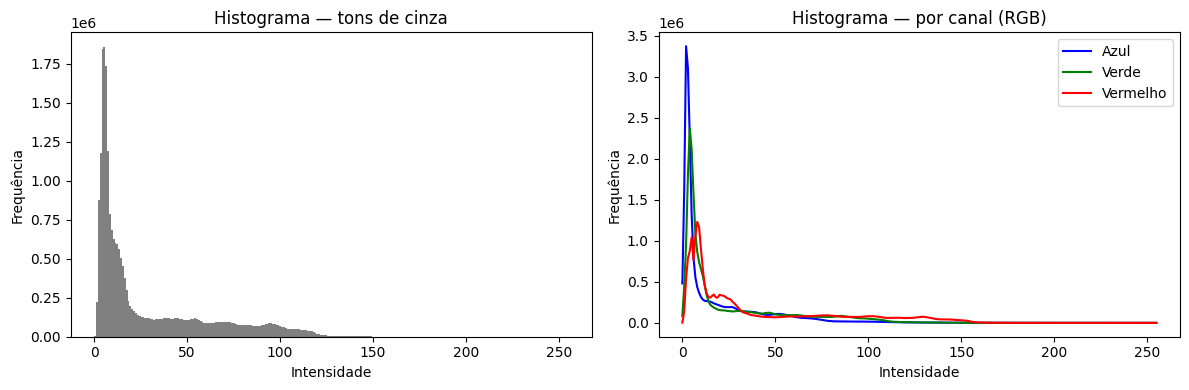

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma em tons de cinza
axes[0].hist(gray_image.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Histograma — tons de cinza')
axes[0].set_xlabel('Intensidade')
axes[0].set_ylabel('Frequência')

# Histograma por canal (B, G, R — ordem nativa do OpenCV)
cores = ('b', 'g', 'r')
nomes = ('Azul', 'Verde', 'Vermelho')
for i, (cor, nome) in enumerate(zip(cores, nomes)):
    canal_hist = cv2.calcHist([cv_image], [i], None, [256], [0, 256])
    axes[1].plot(canal_hist, color=cor, label=nome)
axes[1].set_title('Histograma — por canal (RGB)')
axes[1].set_xlabel('Intensidade')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

### TODO 1.7 - salve o resultado (p1_output_1.jpg)


In [39]:
output_path = OUT_FOLDER / 'p1_output_1.jpg'
sucesso = cv2.imwrite(str(output_path), cv_image)

if not sucesso:
    raise IOError(f"Falha ao salvar imagem em {output_path}")

print(f"Imagem salva em: {output_path.resolve()}")

Imagem salva em: /content/resultados/p1_output_1.jpg


## Realce no domínio espacial
### Objetivos
Aplicar operações diretamente sobre os pixels para melhorar contraste, iluminação ou nitidez. Compare pelo menos duas técnicas, como transformação de intensidade, equalização de histograma, CLAHE, suavização ou aguçamento. (Escolha o que parece mais adequado de acordo com as conclusões feitas em P1)

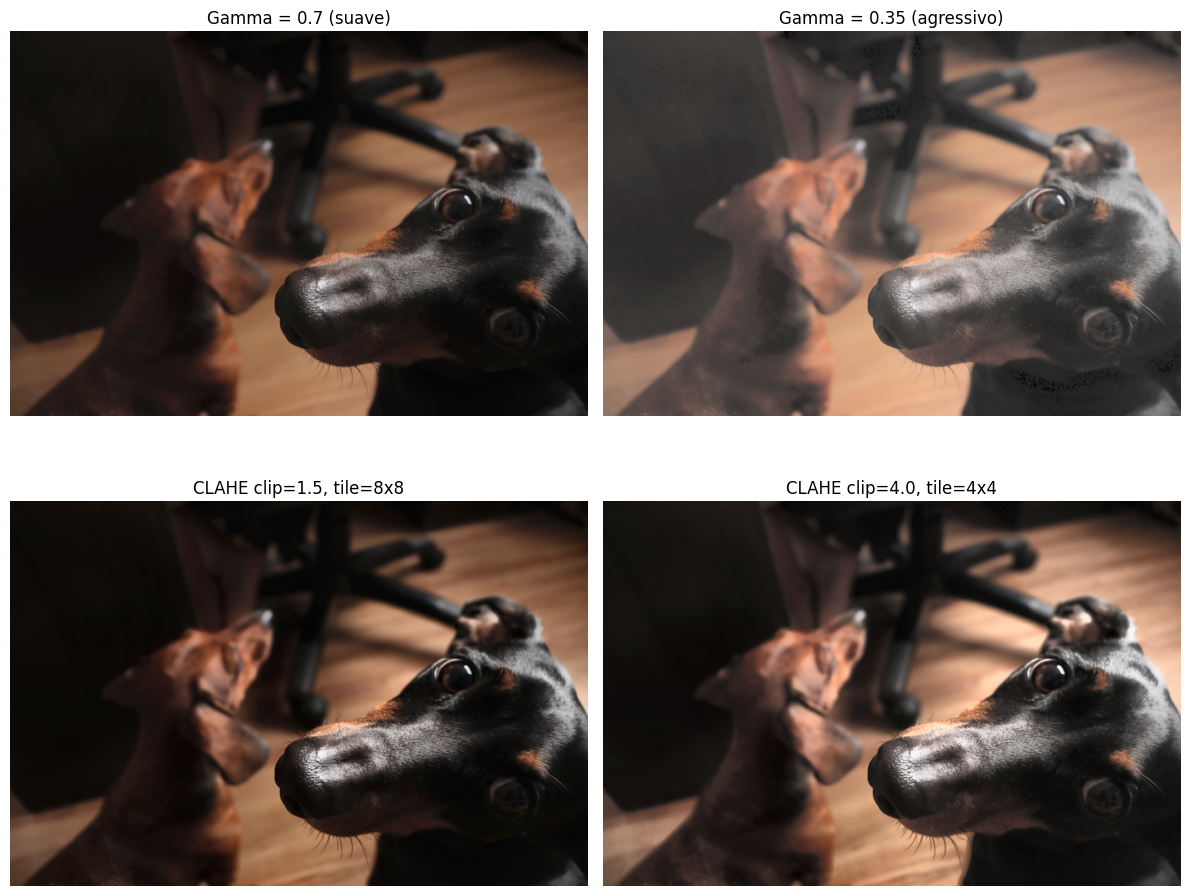

Resultados salvos com sucesso.


In [40]:
# TODO 2.1 — implemente/aplique a primeira técnica de realce (correção gamma)
def ajustar_gamma(imagem_bgr, gamma):
    """Aplica correção gamma apenas no canal de luminância, preservando cor."""
    lab = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    L_norm = L / 255.0
    L_gamma = np.power(L_norm, gamma) * 255.0
    L_gamma = L_gamma.astype(np.uint8)

    lab_ajustado = cv2.merge([L_gamma, a, b])
    return cv2.cvtColor(lab_ajustado, cv2.COLOR_LAB2BGR)

GAMMA = 0.5  # gamma < 1 clareia a imagem (bom para subexposição)
realce_1 = ajustar_gamma(cv_image, GAMMA)

# TODO 2.2 — implemente/aplique a segunda técnica (CLAHE)
def aplicar_clahe(imagem_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Aplica CLAHE apenas no canal de luminância (LAB), preservando cor."""
    lab = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    L_clahe = clahe.apply(L)

    lab_ajustado = cv2.merge([L_clahe, a, b])
    return cv2.cvtColor(lab_ajustado, cv2.COLOR_LAB2BGR)

CLIP_LIMIT = 3.0
TILE_GRID = (8, 8)
realce_2 = aplicar_clahe(cv_image, CLIP_LIMIT, TILE_GRID)


# TODO 2.3 — teste dois conjuntos de parâmetros de acordo com a técnica escolhida
# Gamma: um valor mais suave e um mais agressivo
gamma_suave = ajustar_gamma(cv_image, gamma=0.7)
gamma_agressivo = ajustar_gamma(cv_image, gamma=0.35)

# CLAHE: clip limit baixo (mais conservador) vs alto (mais agressivo)
clahe_conservador = aplicar_clahe(cv_image, clip_limit=1.5, tile_grid_size=(8, 8))
clahe_agressivo = aplicar_clahe(cv_image, clip_limit=4.0, tile_grid_size=(4, 4))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
titulos_imagens = [
    (gamma_suave, 'Gamma = 0.7 (suave)'),
    (gamma_agressivo, 'Gamma = 0.35 (agressivo)'),
    (clahe_conservador, 'CLAHE clip=1.5, tile=8x8'),
    (clahe_agressivo, 'CLAHE clip=4.0, tile=4x4'),
]
for ax, (img, titulo) in zip(axes.ravel(), titulos_imagens):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(titulo)
    ax.axis('off')
plt.tight_layout()
plt.show()


# TODO 2.4 — salve os resultados em OUT_FOLDER
cv2.imwrite(str(OUT_FOLDER / 'p2_output_1.jpg'), realce_1)
cv2.imwrite(str(OUT_FOLDER / 'p2_output_2.jpg'), realce_2)
print("Resultados salvos com sucesso.")